In [51]:
# Importação das bibliotecas
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [52]:
df = pd.read_csv('data_balanceado_sem_pre_diabetes.csv')
df

,Diabetes_012,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,GenHlth,Sex,Age
0,1.0,1.0,1.0,29.0,0.0,1.0,0.0,1.0,3.0,0.0,12.0
1,0.0,0.0,0.0,26.0,0.0,1.0,1.0,1.0,2.0,1.0,4.0
2,0.0,1.0,0.0,34.0,0.0,1.0,1.0,1.0,3.0,0.0,12.0
3,0.0,1.0,1.0,26.0,1.0,1.0,0.0,1.0,2.0,1.0,11.0
4,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,3.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...
42443,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0
42444,0.0,1.0,0.0,32.0,1.0,1.0,1.0,1.0,3.0,0.0,11.0
42445,1.0,0.0,1.0,26.0,0.0,1.0,1.0,1.0,1.0,1.0,11.0
42446,0.0,0.0,0.0,20.0,1.0,1.0,1.0,1.0,2.0,0.0,8.0


In [53]:
X = df.iloc[:,1:].astype(int).values
y = df.iloc[:,0].astype(int).values
X, y

(array([[ 1,  1, 29, ...,  3,  0, 12],
        [ 0,  0, 26, ...,  2,  1,  4],
        [ 1,  0, 34, ...,  3,  0, 12],
        ...,
        [ 0,  1, 26, ...,  1,  1, 11],
        [ 0,  0, 20, ...,  2,  0,  8],
        [ 0,  1, 34, ...,  3,  0,  7]]),
 array([1, 0, 0, ..., 1, 0, 0]))

In [54]:
# Criação e treinamento do modelo
arvores = RandomForestClassifier(n_estimators=100, max_depth=11, min_samples_split=9, random_state=42)

In [55]:
# K-Fold estratificado
# shuffle=True aleatoriza a ordem das entradas em X
kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

In [56]:
# Treinamento do modelo
scores = cross_val_score(arvores, X, y, cv=kfold, scoring='f1')
print(f"F1 score por fold: {scores}")
print(f"F1 score médio: {scores.mean():.4f} ± {scores.std():.4f}")

F1 score por fold: [0.73693629 0.73485529 0.74014756 0.74362199]
F1 score médio: 0.7389 ± 0.0033


In [57]:
# Predição 
y_pred = cross_val_predict(arvores, X, y, cv=kfold)

### MÉTRICAS

In [58]:
print("\nRelatório de Classificação:")
print(classification_report(y, y_pred, digits=4))


Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.7508    0.6765    0.7117     21224
           1     0.7056    0.7754    0.7389     21224

    accuracy                         0.7260     42448
   macro avg     0.7282    0.7260    0.7253     42448
weighted avg     0.7282    0.7260    0.7253     42448



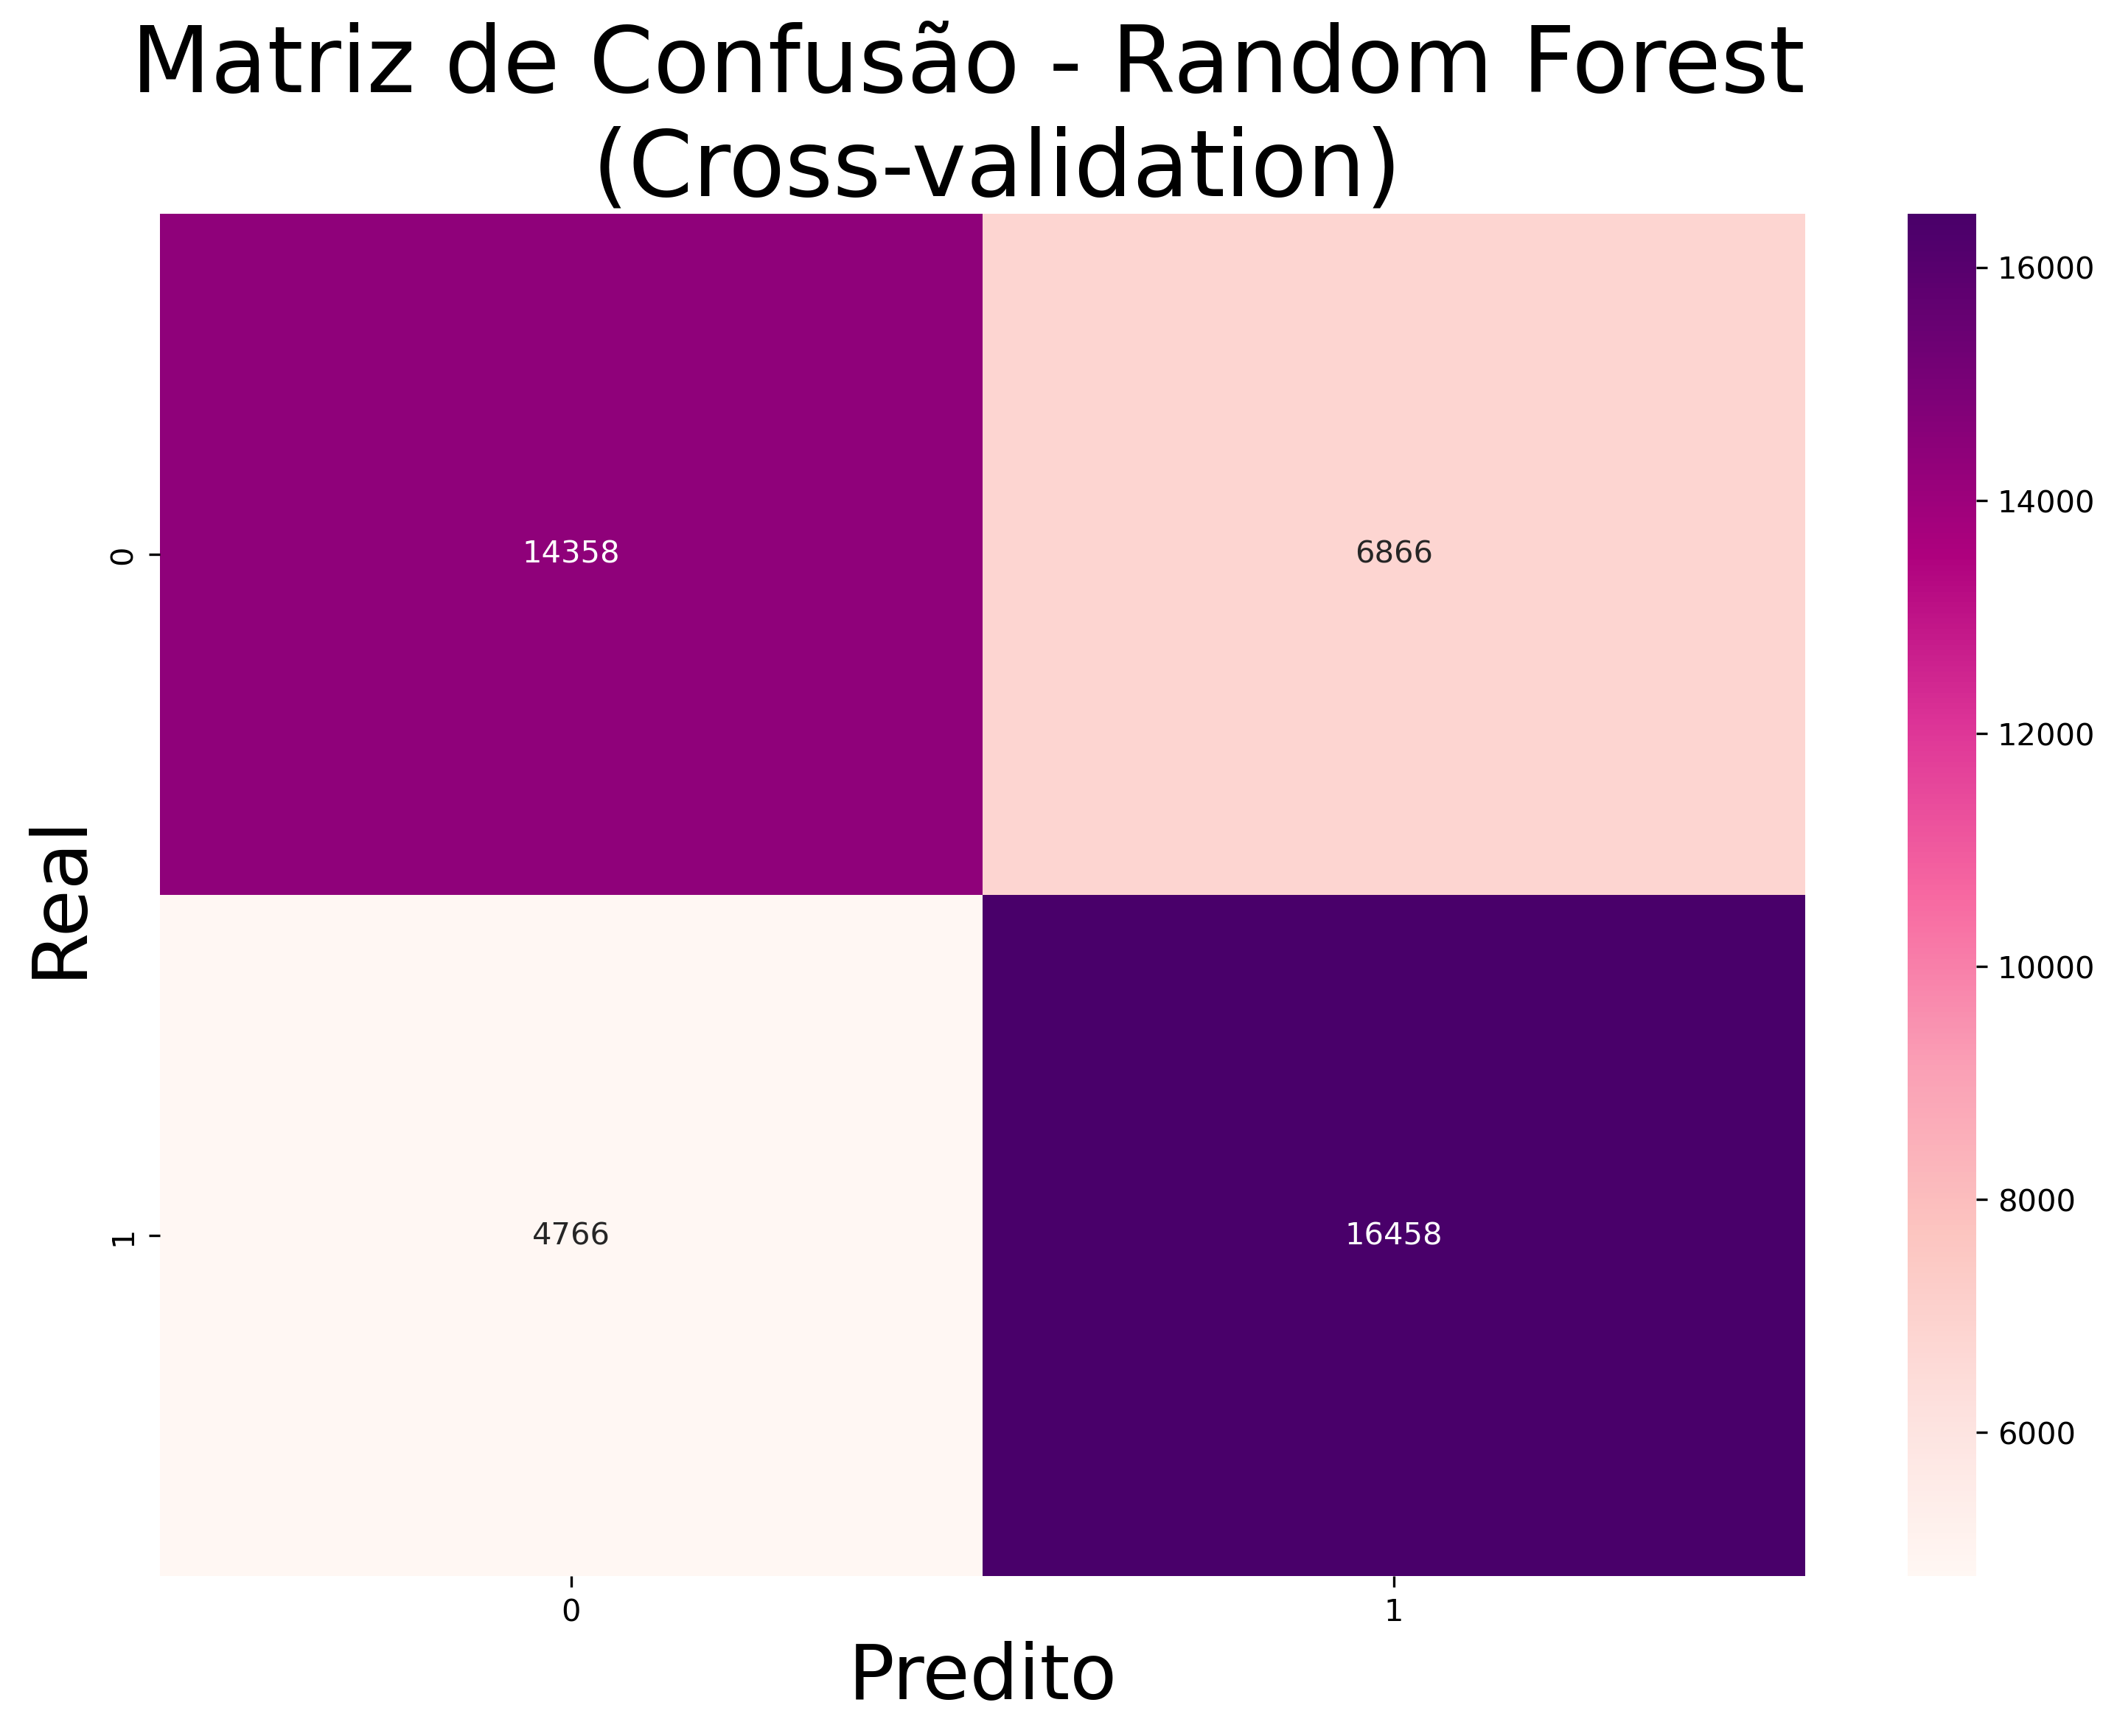

In [59]:
#matriz de confusão
confusao = confusion_matrix(y, y_pred)
confusao

plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(confusao, annot=True, fmt="d", cmap="RdPu")
plt.xlabel("Predito",fontsize=25)
plt.ylabel("Real",fontsize =25)
plt.title("Matriz de Confusão - Random Forest \n (Cross-validation)", fontsize=30)
plt.savefig("random_forest_matriz_confusao_crossvalidation.png", dpi=300)

In [60]:
#taxa acerto
taxa_acerto = accuracy_score(y, y_pred)
taxa_acerto

0.7259705993215229

In [61]:
#taxa erro
taxa_erro = 1 - taxa_acerto
taxa_erro

0.27402940067847714

### CURVA ROC

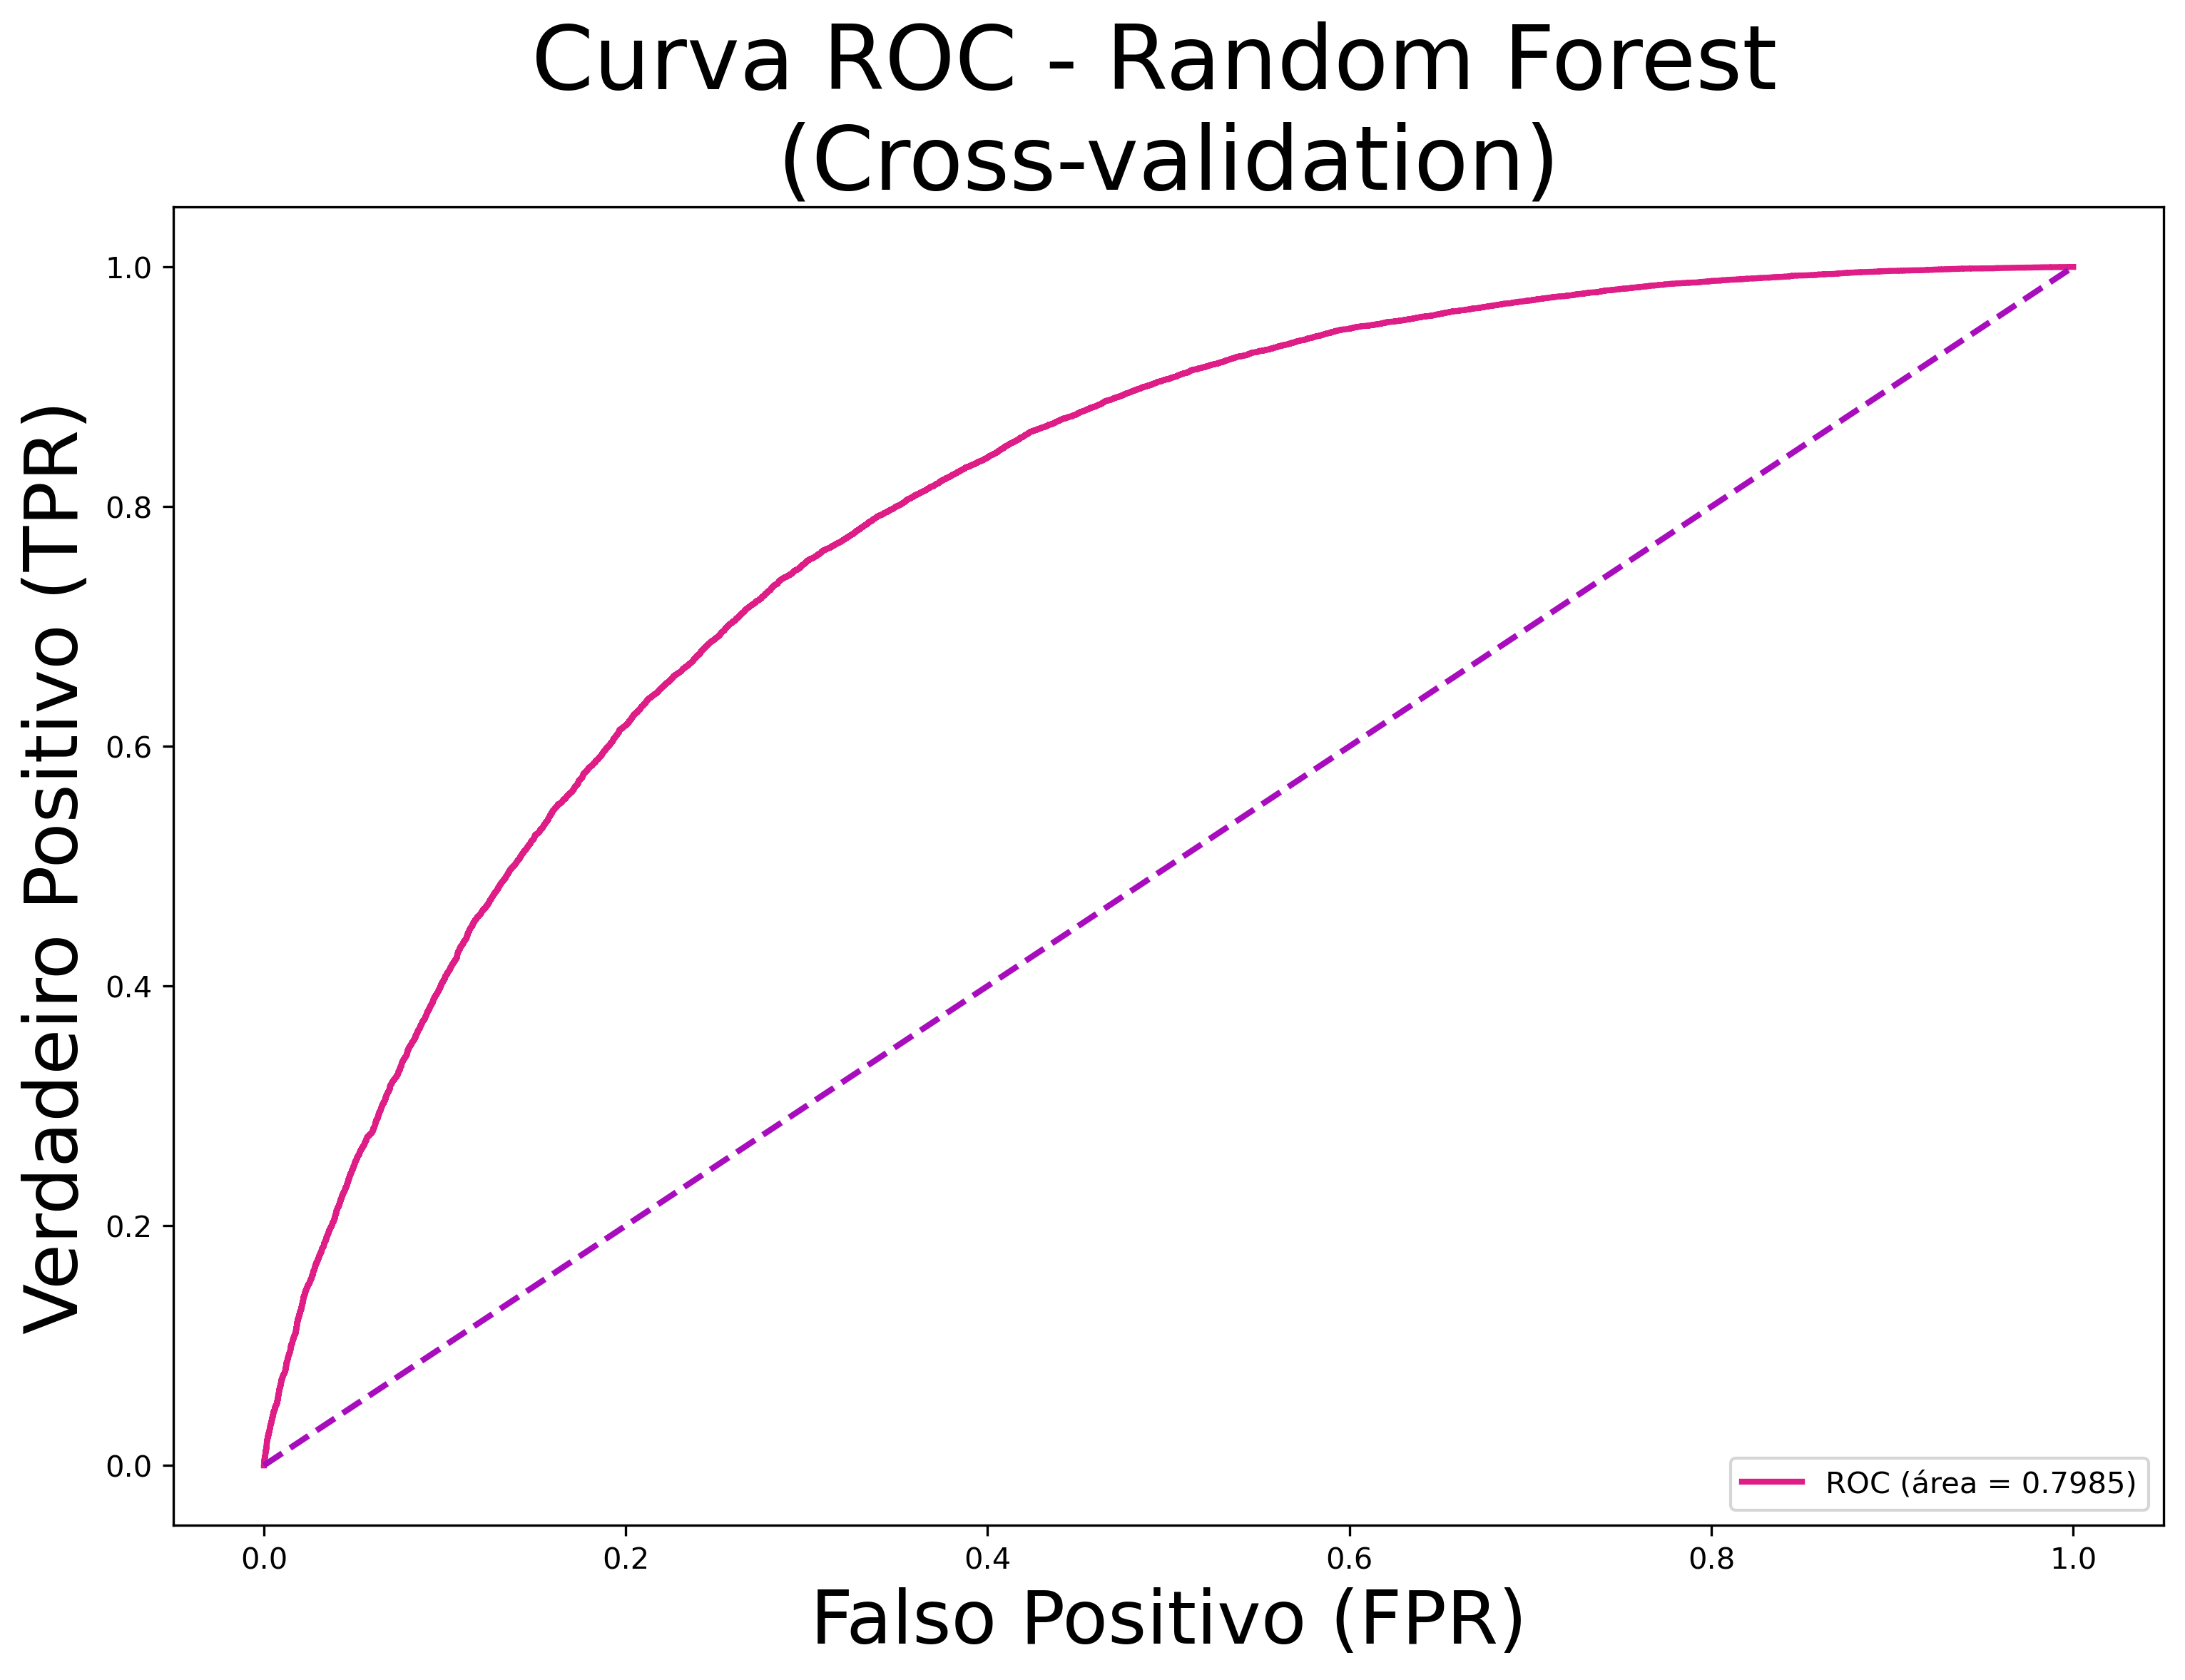

In [62]:
# Probabilidades previstas para a classe positiva (1) -> diabético
y_prob = cross_val_predict(arvores, X, y, cv=kfold, method='predict_proba')[:, 1]

# Calcula FPR, TPR e thresholds
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Calcula a área sob a curva (AUC)
roc_auc = auc(fpr, tpr)

# Plotando a curva ROC
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(fpr, tpr, color='#de1d87', lw=2, label=f'ROC (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#a80dbd', lw=2, linestyle='--')  # linha de referência
plt.xlabel('Falso Positivo (FPR)', fontsize=25)
plt.ylabel('Verdadeiro Positivo (TPR)', fontsize=25)
plt.title('Curva ROC - Random Forest \n(Cross-validation)', fontsize=30)
plt.legend(loc="lower right")
plt.savefig("decision_random_forest_roc_crossvalidation.png", dpi=300)
